In [1]:
# ===========================================
# Import Required Libraries
# ===========================================

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
print("PyTorch Version :", torch.__version__)

PyTorch Version : 2.13.0+cpu


In [3]:
# ============================================
# Image Transform
# ============================================

IMAGE_SIZE = 224
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

print("Image Transform Created Successfully!")

Image Transform Created Successfully!


In [4]:
# ============================================
# Load Dataset
# ============================================

TRAIN_PATH = "../data/chest_xray/train"
VAL_PATH   = "../data/chest_xray/val"
TEST_PATH  = "../data/chest_xray/test"

train_dataset = ImageFolder(TRAIN_PATH, transform=transform)
val_dataset   = ImageFolder(VAL_PATH, transform=transform)
test_dataset  = ImageFolder(TEST_PATH, transform=transform)

print("Datasets Loaded Successfully!")

print("\nTraining Images :", len(train_dataset))
print("Validation Images :", len(val_dataset))
print("Testing Images :", len(test_dataset))

print("\nClasses :", train_dataset.classes)

Datasets Loaded Successfully!

Training Images : 5216
Validation Images : 16
Testing Images : 624

Classes : ['NORMAL', 'PNEUMONIA']


In [5]:
# ============================================
# Create DataLoaders
# ============================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders Created Successfully!")

DataLoaders Created Successfully!


In [6]:
# ============================================
# Check One Batch
# ============================================

images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Batch Shape : torch.Size([32])


In [7]:
# ============================================
# Load Pretrained ResNet18
# ============================================

from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

print("Pretrained ResNet18 Loaded Successfully!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\pruth/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:03<00:00, 15.1MB/s]

Pretrained ResNet18 Loaded Successfully!


In [8]:
# ============================================
# View ResNet18 Architecture
# ============================================

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [9]:
# ============================================
# Modify Final Layer
# ============================================

NUM_CLASSES = 2

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

print("Final Layer Modified Successfully!")
print(model.fc)

Final Layer Modified Successfully!
Linear(in_features=512, out_features=2, bias=True)


In [10]:
# ============================================
# Freeze Pretrained Layers
# ============================================

for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

print("Pretrained Layers Frozen Successfully!")

Pretrained Layers Frozen Successfully!


In [11]:
# ============================================
# Check Trainable Parameters
# ============================================

trainable_params = 0
total_params = 0

for param in model.parameters():
    total_params += param.numel()

    if param.requires_grad:
        trainable_params += param.numel()

print("Total Parameters :", total_params)
print("Trainable Parameters :", trainable_params)

Total Parameters : 11177538
Trainable Parameters : 1026


In [12]:
# ============================================
# Define Loss Function
# ============================================

criterion = nn.CrossEntropyLoss()

print("Loss Function Created Successfully!")
print(criterion)

Loss Function Created Successfully!
CrossEntropyLoss()


In [13]:
# ============================================
# Define Optimizer
# ============================================

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("Optimizer Created Successfully!")
print(optimizer)

Optimizer Created Successfully!
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [14]:
# ============================================
# Select Device
# ============================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Device :", device)

Device : cpu


In [15]:
# ============================================
# Training Configuration
# ============================================

EPOCHS = 5

print("Training Configuration Ready!")
print("Epochs :", EPOCHS)

Training Configuration Ready!
Epochs : 5


In [16]:
# ============================================
# Train ResNet18
# ============================================

train_losses = []

for epoch in range(EPOCHS):

    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] Loss : {epoch_loss:.4f}")

Epoch [1/5] Loss : 0.2466
Epoch [2/5] Loss : 0.1600
Epoch [3/5] Loss : 0.1405
Epoch [4/5] Loss : 0.1349
Epoch [5/5] Loss : 0.1245


In [17]:
# ============================================
# Save ResNet18 Model
# ============================================

MODEL_PATH = "../models/resnet18_pneumonia.pth"

torch.save(model.state_dict(), MODEL_PATH)

print("ResNet18 Model Saved Successfully!")

ResNet18 Model Saved Successfully!


In [18]:
# ============================================
# Evaluation Mode
# ============================================

model.eval()

print("Model is now in Evaluation Mode!")

Model is now in Evaluation Mode!


In [19]:
# ============================================
# Prediction Lists
# ============================================

all_predictions = []
all_labels = []

print("Prediction Lists Created Successfully!")

Prediction Lists Created Successfully!


In [20]:
# ============================================
# Evaluate ResNet18
# ============================================

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Evaluation Completed Successfully!")

Evaluation Completed Successfully!


In [21]:
# ============================================
# Calculate Accuracy
# ============================================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(all_labels, all_predictions)

print(f"ResNet18 Test Accuracy : {accuracy*100:.2f}%")

ResNet18 Test Accuracy : 81.25%


In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_predictions)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[121 113]
 [  4 386]]


In [23]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_predictions,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

      NORMAL       0.97      0.52      0.67       234
   PNEUMONIA       0.77      0.99      0.87       390

    accuracy                           0.81       624
   macro avg       0.87      0.75      0.77       624
weighted avg       0.85      0.81      0.80       624



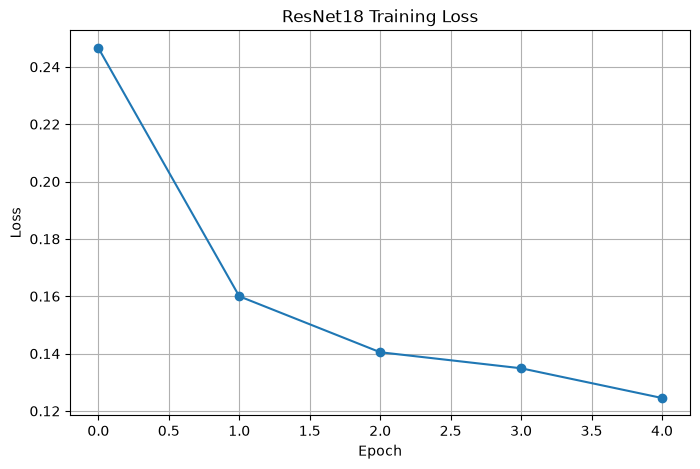

In [24]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, marker='o')

plt.title("ResNet18 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.show()